## KST Transformer - Izveštaj

### Cilj projekta

Cilj projekta je treniranje transformer modela koji replicira **IITA (Inductive Item Tree Analysis)** algoritam iz **Knowledge Space Theory (KST)**.

IITA algoritam rekonstruiše **prerequisit relacije** između pitanja na osnovu matrice odgovora studenata. Ove relacije opisuju koji koncepti moraju biti usvojeni pre nego što student može uspešno odgovoriti na određeno pitanje.

Transformer model uči da iz iste matrice odgovora direktno predvidi **adjacency matricu prerequisita**, bez eksplicitnog pokretanja IITA algoritma - što je računski znatno efikasnije.

---

### Osnovni koncepti

- **Pitanje (item)**: zadatak koji student može rešiti ili ne
- **Prerequisit relacija** `i -> j`: pitanje `i` je prerequisit pitanja `j` - student koji zna `j` mora znati i `i`
- **Quasi-order**: tranzitivna i refleksivna relacija prerequisita

### 1. Generisanje dataseta

**Fajl:** `scripts/generate_dataset.py`

Dataset se sintetički generiše koristeći `learning_spaces` biblioteku. Svaki primer (test) sadrži:
- `X` - binarna matrica odgovora studenata oblika `(students, items)` (1 -> tačan odgovor, 0 -> netačan odgovor)
- `Y` - adjacency matrica prerequisita oblika `(items, items)` - bez tranzitivnog zatvorenja (ukoliko `a->b` i `b->c`, matrica ne sadrzi i `a->c`)
- `item_count` - stvarni broj pitanja u primeru (ostalo je padding nulama)

### Pipeline generisanja jednog primera

1. Nasumično se bira broj pitanja `n` iz `[min_items, max_items]` (broj pitanja se bira uniformno ili po linearnim tezinama)
2. Generišu se nasumične implikacije kao DAG (topološka permutacija garantuje da relacije mogu ići u bilo kom smeru)
3. Računa se **tranzitivno zatvorenje** nad skupom implikacija - šalje se `simu()` funkciji
4. `simu()` simulira odgovore uz šum: `ce` (careless error) i `lg` (lucky guess)
5. Računa se **tranzitivna redukcija** - čuva se kao `Y`
6. Response matrica i adj matrica se padduju na `max_items`

### Topološka permutacija

Bez permutacije, implikacije bi uvek imale oblik `i -> j` gde je `i < j` (gornji trougao). Na taj način bi uveli određeni šablon na izlazu koji bi model mogao da nauči. Permutacija to sprečava:

```python
topo     = np.random.permutation(items)
possible = [(int(topo[i]), int(topo[j])) for i in range(items) for j in range(i+1, items)]
```

### Parametri šuma

| Parametar | Vrednost | Opis |
|-----------|----------|------|
| `ce` | 0.10 | Careless error - student koji zna odgovor ipak greši |
| `lg` | 0.05 | Lucky guess - student koji ne zna ipak odgovori tačno |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('data/kst_dataset_2-10items_80k_weighted.npz')
X, Y, item_counts = data['X'], data['Y'], data['item_counts']

print(f'Broj uzoraka:      {X.shape[0]}')
print(f'Studenata/uzorak:  {X.shape[1]}')
print(f'Max items:         {X.shape[2]}')
print()
print('Distribucija broja pitanja po uzorku:')
for k in range(2, 11):
    cnt = (item_counts == k).sum()
    print(f'  {k:2d} pitanja: {cnt:5d} uzoraka ({100*cnt/len(item_counts):.1f}%)')

Broj uzoraka:      80000
Studenata/uzorak:  500
Max items:         10

Distribucija broja pitanja po uzorku:
   2 pitanja:  1837 uzoraka (2.3%)
   3 pitanja:  3561 uzoraka (4.5%)
   4 pitanja:  5319 uzoraka (6.6%)
   5 pitanja:  7189 uzoraka (9.0%)
   6 pitanja:  8776 uzoraka (11.0%)
   7 pitanja: 10603 uzoraka (13.3%)
   8 pitanja: 12263 uzoraka (15.3%)
   9 pitanja: 14393 uzoraka (18.0%)
  10 pitanja: 16059 uzoraka (20.1%)


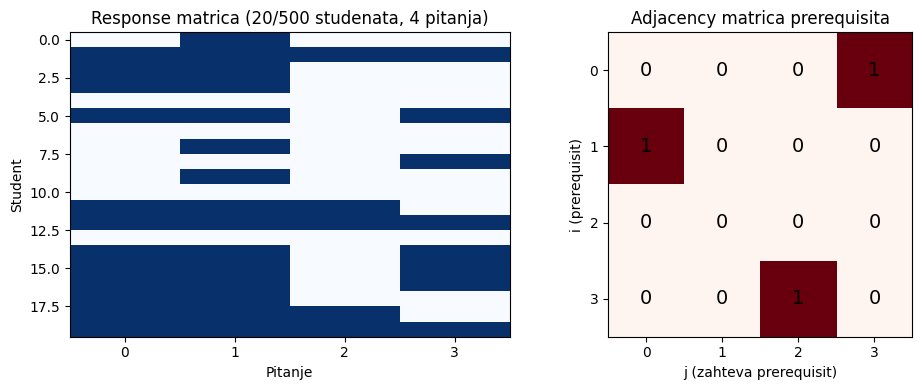

item_count = 4


In [2]:
idx = 10
n   = item_counts[idx]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(X[idx, :20, :n], cmap='Blues', vmin=0, vmax=1, aspect='auto')
axes[0].set_title(f'Response matrica (20/{X.shape[1]} studenata, {n} pitanja)')
axes[0].set_xlabel('Pitanje')
axes[0].set_ylabel('Student')
axes[0].set_xticks(range(n))

axes[1].imshow(Y[idx, :n, :n], cmap='Reds', vmin=0, vmax=1)
axes[1].set_title('Adjacency matrica prerequisita')
axes[1].set_xlabel('j (zahteva prerequisit)')
axes[1].set_ylabel('i (prerequisit)')
axes[1].set_xticks(range(n))
axes[1].set_yticks(range(n))
for i in range(n):
    for j in range(n):
        axes[1].text(j, i, str(int(Y[idx, i, j])), ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()
print(f'item_count = {n}')

### 2. Dataset klasa

**Fajl:** `src/kst/dataset.py`

### KSTDataset

PyTorch `Dataset` koji učitava `.npz` fajl i vraća trojku `(X, Y, item_count)` po uzorku.

### make_loss_mask

Kreira boolean masku oblika `(batch, max_items, max_items)` - `True` tamo gde treba računati gubitak. Maskiraju se padding ćelije i dijagonala:

```python
idx        = torch.arange(max_items)
valid      = idx.unsqueeze(0) < item_counts.unsqueeze(1)       # (batch, max_items)
valid_pair = valid.unsqueeze(2) & valid.unsqueeze(1)           # (batch, max_items, max_items)
diag_mask  = ~torch.eye(max_items, dtype=torch.bool).unsqueeze(0)
return valid_pair & diag_mask
```

In [3]:
import sys
sys.path.insert(0, 'src')

import torch
from kst.dataset import make_dataloaders, make_loss_mask

train_loader, val_loader, test_loader = make_dataloaders(
    'data/kst_dataset_2-10items_80k_weighted.npz',
    batch_size=64, val_ratio=0.2, test_ratio=0.1, seed=42,
)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')
print(f'Test  batches: {len(test_loader)}')

X_b, Y_b, ic_b = next(iter(train_loader))
print(f'\nX oblik:         {X_b.shape}   (batch, students, items)')
print(f'Y oblik:         {Y_b.shape}   (batch, items, items)')
print(f'item_counts[:5]: {ic_b[:5].tolist()}')

mask = make_loss_mask(ic_b, max_items=X_b.shape[-1])
print(f'\nLoss maska primer [0] (item_count={ic_b[0]}):')
print(mask[10].int())

Train batches: 875
Val   batches: 250
Test  batches: 125

X oblik:         torch.Size([64, 500, 10])   (batch, students, items)
Y oblik:         torch.Size([64, 10, 10])   (batch, items, items)
item_counts[:5]: [5, 3, 10, 10, 9]

Loss maska primer [0] (item_count=5):
tensor([[0, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [1, 0, 1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 0, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 0, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=torch.int32)


### 3. Arhitektura modela

**Fajl:** `src/kst/model.py`

Model je **encoder-only transformer** koji procesira pitanja kao tokene i za svaki par predviđa prerequisit relaciju.

```
Ulaz: (batch, students, items)
    -  Transpose
(batch, items, students)
    -  Input Projection: Linear(students -> d_model)
(batch, items, d_model)
      + Learned Positional Encoding: Embedding(max_items, d_model)
    -  Transformer Encoder [sa padding maskom]
h: (batch, items, d_model)
    -  Pair Classifier
       konkatenira h_i i h_j za svaki par (i, j)
       Linear(2*d_model -> d_model) -> ReLU -> Dropout -> Linear(d_model -> 1)
Izlaz: (batch, items, items) - logiti
```

**Padding maska**: `src_key_padding_mask` u PyTorch TransformerEncoder-u - `True` = ignoriši tu poziciju u attention-u. Sprečava model da vidi paddovana pitanja.

**Logiti**: Model vraća logite (bez sigmoid). `BCEWithLogitsLoss` interno primenjuje sigmoid za numeričku stabilnost.

In [15]:
from kst.model import KSTTransformer

# Najbolji hiperparametri (strict model, 10 pitanja) - random search
model = KSTTransformer(
    max_items=10, students=500,
    d_model=128, nhead=4, num_encoder_layers=4,
    dim_feedforward=128, dropout=0.1,
)

total = sum(p.numel() for p in model.parameters())
print(f'Ukupno parametara: {total:,}\n')
print(model)

Ukupno parametara: 496,769

KSTTransformer(
  (input_projection): Linear(in_features=500, out_features=128, bias=True)
  (positional_encoding): Embedding(10, 128)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (pair_classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.

In [5]:
x_test  = torch.randint(0, 2, (4, 500, 10)).float()
ic_test = torch.tensor([10, 7, 5, 2])
out     = model(x_test, ic_test)
print(f'Ulaz:  {x_test.shape}  (batch=4, students=500, max_items=10)')
print(f'Izlaz: {out.shape}   (batch=4, items=10, items=10) - logiti')

Ulaz:  torch.Size([4, 500, 10])  (batch=4, students=500, max_items=10)
Izlaz: torch.Size([4, 10, 10])   (batch=4, items=10, items=10) - logiti


### 4. Random Search hiperparametara

**Fajl:** `scripts/random_search.py`

Umesto ručnog podešavanja hiperparametara, korišćen je **random search**: nasumično se uzorkuju kombinacije hiperparametara, svaka se trenira ograničen broj epoha, i bira se kombinacija sa najnižim `val_loss`.

### Prostor pretrage

| Hiperparametar | Opseg |
|----------------|-------|
| `d_model` | {64, 128, 256, 384} |
| `nhead` | {2, 4, 8, 16} (samo delioci `d_model`) |
| `num_layers` | {2, 3, 4, 5, 6} |
| `dim_feedforward` | {128, 256, 512, 1024} |
| `dropout` | {0.1, 0.2, 0.3} |
| `batch_size` | {32, 64, 128} |
| `lr` | log-uniform [1e-4, 1e-3] |

Akumulirano je **172 trial-a** (uz dedup već isprobanih kombinacija preko `--history` fajla), svaki treniran najviše 30 epoha sa early stopping patience=10.

In [6]:
import pandas as pd

df = pd.read_csv('report material/random_search_10items.csv')
df = df.sort_values('val_loss').reset_index(drop=True)
df.index += 1

print('Top 10 kombinacija (sortirano po val_loss):')
print(df[['val_loss','d_model','nhead','num_layers','dim_feedforward','dropout','batch_size','lr']].head(10).to_string())

Top 10 kombinacija (sortirano po val_loss):
               val_loss  d_model  nhead  num_layers  dim_feedforward  dropout  batch_size        lr
1    0.3637368212938309    128.0    4.0         4.0            128.0      0.1        64.0  0.000906
2      0.37125992000103     64.0   16.0         4.0           1024.0      0.1        32.0  0.000812
3    0.3715676168203354    256.0   16.0         5.0            128.0      0.1        32.0  0.000794
4   0.37507383728027344     64.0    8.0         6.0            512.0      0.1       128.0  0.000704
5   0.37518739184737204    384.0   16.0         5.0            512.0      0.1        32.0  0.000489
6   0.37528527176380155     64.0    8.0         6.0           1024.0      0.1        64.0  0.000532
7    0.3770510493516922    128.0   16.0         5.0           1024.0      0.1        64.0  0.000166
8    0.3772323825955391    256.0   16.0         6.0            128.0      0.2        32.0  0.000651
9   0.37774520844221116    128.0   16.0         5.0     

#### Izabrani hiperparametri

| Parametar | Vrednost |
|-----------|----------|
| `d_model` | 128 |
| `nhead` | 4 |
| `num_layers` | 4 |
| `dim_feedforward` | 128 |
| `dropout` | 0.1 |
| `batch_size` | 64 |
| `lr` | 0.000906 |

### 5. Trening

**Fajl:** `scripts/train.py`

### Loss funkcija

**Binary Cross-Entropy with Logits** sa `pos_weight` parametrom koji kompenzuje neravnotežu klasa (~88% nula, ~12% jedinica):

$$\text{pos\_weight} = \frac{\text{broj nula}}{\text{broj jedinica}} \approx 7.6$$

Loss se računa samo na validnim ćelijama (bez paddinga i dijagonale), uz pomoć `make_loss_mask`.

### Evaluacione metrike

| Metrika | Formula |
|---------|---------|
| **F1** | $2TP / (2TP + FP + FN)$ |
| **Hamming loss** | $(FP + FN) / \text{ukupno}$ |

Obe metrike se prosecavaju po uzorcima (makro prosek). Uzorci bez prerequisita dobijaju F1 = 1.0 ako je predikcija ispravno prazna.

![](report%20material/plots/training_curves_10_items_200epochs.png)

### 5.1 Leniency - opuštenost

Ground truth `Y` je **Hasse dijagram** - sadrži samo *direktne* prerequisit ivice (tranzitivna redukcija). Zbog toga strict trening ima jednu neželjenu osobinu: ako model predvidi vezu koja je **logički tačna ali redundantna**, strict loss je kažnjava kao lažno pozitivnu.

Primer: ako postoji lanac `0 → 1 → 2`, onda je i veza `0 → 2` zapravo ispravna (student koji zna pitanje `2` zna i `1`, pa samim tim i `0`). Ali u `Y` ta veza ne postoji kao direktna ivica, pa je strict loss tretira kao grešku i tera model da je *ne* predvidi.

**Ideja opuštenosti (leniency):** takve tranzitivno-implicirane, ali ne-direktne ćelije jednostavno **izbacujemo iz loss-a** - model se za njih niti nagrađuje niti kažnjava. Na taj način ne prisiljavamo model da uči veštačku razliku između "direktne" i "izvedene" veze koja je logički svejedno tačna - pustamo ga da u prostoru relacija uzrokovanih tranzitivnoscu sam generalizuje.

**Ukratko: celije tranzitivnih veza i padding-a se tretiraju na isti nacin u lenient loss maski.**

#### Kako se gradi lenient maska

Polazimo od osnovne maske (`make_loss_mask`, koja već izuzima padding i dijagonalu) i iz nje dodatno uklanjamo ćelije koje su u tranzitivnom zatvorenju `Y`, ali nisu direktna Hasse ivica:

```python
def make_lenient_loss_mask(Y, base_mask):
    closed          = batched_transitive_closure(Y.bool())  # puno tranzitivno zatvorenje
    transitive_only = closed & ~Y.bool()                    # implicirane, ne-direktne veze
    return base_mask & ~transitive_only                     # izbaci ih iz loss-a
```

Za lanac `0 → 1 → 2` (tj. `Y[0,1] = Y[1,2] = 1`):

| ćelija | strict maska | lenient maska | razlog |
|---|:---:|:---:|---|
| `(0,1)`, `(1,2)` | ✓ u loss-u | ✓ u loss-u | direktne Hasse ivice |
| `(0,2)` | ✓ u loss-u (cilj = 0) | ✗ izuzeta | tranzitivno implicirana |
| dijagonala, padding | ✗ | ✗ | uvek maskirane |

#### Šta se menja u treningu

Trening petlja je identična - menja se **samo maska** koja ulazi u loss (uključuje se zastavicom `--lenient-loss`):

```python
mask = make_loss_mask(item_counts, max_items)
if lenient:
    mask = make_lenient_loss_mask(Y, mask)
loss = F.binary_cross_entropy_with_logits(pred[mask], Y[mask], pos_weight=pos_weight)
```

Bitno: `pos_weight` (odnos nula i jedinica) se računa nad **istom** maskom koja se koristi za loss, pa ostaje konzistentan sa izabranim režimom - izbacivanjem tranzitivnih ćelija menja se i balans klasa.

Kao rezultat treniramo **dva modela** koja delе identičnu arhitekturu i hiperparametre (ne i vrednosti hiperparametara), a razlikuju se samo po maski:

- **strict model** - `make_loss_mask` (kažnjava i redundantne ispravne veze)
- **lenient model** - `make_lenient_loss_mask` (ignoriše redundantne ispravne veze)

![](report%20material/plots/training_curves_10_items_200epochs_lenient.png)

### 6. Evaluacija - KST Transformer vs IITA

**Fajl:** `scripts/eval_iita.py`

Poređenje KST Transformer modela sa IITA algoritmom (v=1,2,3) na istom test skupu.

**Metodologija:**
- Isti test split kao u treningu (seed=42, test_ratio=0.1)
- Oba metoda dobijaju iste ulazne podatke
- IITA se pokreće uzorak po uzorak samo na stvarnim pitanjima (bez paddinga)
- Metrike se računaju po uzorku i usrednjavaju (makro prosek)
- Uzorci bez prerequisita: F1 = 1.0 ako model ispravno predvidi sve nule

In [ ]:
import sys
sys.path.insert(0, 'src')

import time
import numpy as np
import torch
from kst.dataset import make_dataloaders
from kst.model import KSTTransformer
from learning_spaces.kst.iita import iita
from util.metrics import metrics_np, metrics_lenient, metrics_closure
from util.generate_dataset_util import transitive_reduction

DATA        = 'data/kst_dataset_2-10items_80k_weighted.npz'
CHECKPOINT  = 'checkpoints/best_10items_80k_weighted_200epochs.pt'
NUM_SAMPLES = 500

_, _, test_loader = make_dataloaders(DATA, batch_size=64, val_ratio=0.2, test_ratio=0.1, seed=42)
X_all  = torch.cat([x  for x, _, _  in test_loader])
Y_all  = torch.cat([y  for _, y, _  in test_loader])
ic_all = torch.cat([ic for _, _, ic in test_loader])

n_eval = min(NUM_SAMPLES, len(X_all))
X_sub, Y_sub, ic_sub = X_all[:n_eval], Y_all[:n_eval], ic_all[:n_eval]
_, students, max_items = X_sub.shape

# --- IITA v=1, v=2, v=3 ---
# strict  : izlaz IITA se tranzitivno redukuje (Hasse dijagram)
# lenient : sirov izlaz (tranzitivne veze se ne kaznjavaju)
# closure : sirov izlaz vs puno tranzitivno zatvorenje Y
iita_rows = {}
for v in [1, 2, 3]:
    print(f'Pokrecem IITA (v={v}) na {n_eval} uzoraka...')
    s, l, c = [], [], []
    t0 = time.perf_counter()
    for i in range(n_eval):
        k = int(ic_sub[i])
        try:
            impl = [(a, b) for (a, b) in iita(X_sub[i, :, :k].numpy(), v=v)['implications'] if a < k and b < k]
        except Exception:
            continue
        y   = Y_sub[i, :k, :k].numpy()
        red = np.zeros((k, k), np.float32)
        for (a, b) in transitive_reduction(impl):
            red[a][b] = 1.0
        raw = np.zeros((k, k), np.float32)
        for (a, b) in impl:
            raw[a][b] = 1.0
        s.append(metrics_np(red, y, k))
        l.append(metrics_lenient(raw, y, k))
        c.append(metrics_closure(raw, y, k))
    iita_rows[v] = (np.mean(s, 0), np.mean(l, 0), np.mean(c, 0), time.perf_counter() - t0)

# --- Transformer ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt   = torch.load(CHECKPOINT, map_location=device)
sa     = ckpt.get('args', {})
model  = KSTTransformer(
    max_items=max_items, students=students,
    d_model=sa['d_model'], nhead=sa['nhead'],
    num_encoder_layers=sa['num_layers'],
    dim_feedforward=sa['dim_feedforward'], dropout=sa['dropout'],
).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()

t0 = time.perf_counter()
with torch.no_grad():
    logits = model(X_sub.to(device), ic_sub.to(device)).cpu().numpy()
tr_time = time.perf_counter() - t0

ts, tl, tc = [], [], []
for i in range(n_eval):
    k    = int(ic_sub[i])
    pred = (logits[i, :k, :k] > 0).astype(np.float32)   # sigmoid(x) > 0.5  <=>  x > 0
    y    = Y_sub[i, :k, :k].numpy()
    ts.append(metrics_np(pred, y, k))
    tl.append(metrics_lenient(pred, y, k))
    tc.append(metrics_closure(pred, y, k))
tr = (np.mean(ts, 0), np.mean(tl, 0), np.mean(tc, 0), tr_time)

# --- Tabele: strict / lenient / closure ---
for mi, naziv in [(0, 'Strict (Hasse dijagram)'), (1, 'Lenient'), (2, 'Full transitive closure')]:
    print(f'\n{naziv}')
    print(f'{"Metod":<20}{"F1":>8}{"Hamming":>10}{"Vreme (s)":>12}')
    print('-' * 50)
    for v, row in iita_rows.items():
        m = row[mi]
        print(f'{f"IITA (v={v})":<20}{m[0]:>8.3f}{m[1]:>10.3f}{row[3]:>12.1f}')
    m = tr[mi]
    print(f'{"KST Transformer":<20}{m[0]:>8.3f}{m[1]:>10.3f}{tr[3]:>12.1f}')

print(f'\nCheckpoint: epoha {ckpt.get("epoch","?")} | val_loss={ckpt.get("val_loss",0):.4f} | val_F1={ckpt.get("val_f1",0):.3f}')

### Rezultati (Dataset do 5 pitanja)

Pri pokretanju skripte za poredjenje performansi modela u odnosu na sve tri verzije IITA algortima, pri čemu su performanse merene nad skupom podataka od 2000 sample-ova iz test skupa, dobijeni su sledeći rezultati: 

#### Strict (Hasse dijagram)

| Metod | F1 | Hamming loss | Vreme (s) |
|-------|----|--------------| ----- |
| IITA (v=1) | 0.807 | 0.060 | 5.4 |
| IITA (v=2) | 0.806 | 0.061 | 5.0 |
| IITA (v=3) | 0.739 | 0.089 | 4.9 |
| **KST Transformer** | **0.900** | **0.049** | **0.3** |


#### Lenient (tranzitivne veze su tacne - nisu ***false positive***)

| Metod | F1 | Hamming loss | Vreme (s) |
|-------|----|--------------| ----- |
| IITA (v=1) | 0.822 | 0.053 | 5.4 |
| IITA (v=2) | 0.821 | 0.053 | 5.0 |
| IITA (v=3) | 0.772 | 0.077 | 4.9 |
| **KST Transformer** | **0.928** | **0.035** | **0.3** |

### Rezultati (Dataset do 10 pitanja)

#### **Klasican model**
##### Strict evaluacija (Hasse dijagram <=> Ground Truth)

Output iita algoritma i trenirarog modela se porede sa minimalnim skupom implikacija.
Prediktovane tranzitivne veze bi se posmatrale kao ***False positive***
> **Note**: Sobzirom da iita nije ogranicena na minimalan skup implikacija i moze pronaci vezu izmedju bilo koja dva pitanja - na izlazu iita algoritma vrsi se tranzitivna redukcija

<img src="report%20material/plots/10items_80k_200epochs/iita_comparison_best_10items_80k_weighted_200epochs_strict_overall.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs/iita_comparison_best_10items_80k_weighted_200epochs_strict_f1_by_items.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs/iita_comparison_best_10items_80k_weighted_200epochs_strict_hamming_by_items.png" width="60%" style="display: block; margin: 0 auto;">

---

##### Lenient evaluacija

Problem kod strict evaluacije nastaje kada model ili algoritam predvidi zavisnost izmedju 2 pitanja koja se **ne nalazi** u minimalnom skupu implikacija. Ovako prediktovane veze tretiramo kao ***false positive*** iako su tacne - rezultati strict evaluacije mogu u tom smislu zavarati.

Lenient evaluacija tretira ovakve veze na sledeci nacin:  
- ukoliko model ili algoritam **predividi** ovakvu vezu tamo gde je ima - tretiramo je kao ***true positive***  
- ukoliko model ili algoritam **ne predividi** ovakvu vezu tamo gde je ima - ignorise se, promasena tranzitivna veza se **ne kaznjava** (ne tretira kao ***false negative***)

<img src="report%20material/plots/10items_80k_200epochs/iita_comparison_best_10items_80k_weighted_200epochs_lenient_overall.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs/iita_comparison_best_10items_80k_weighted_200epochs_lenient_f1_by_items.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs/iita_comparison_best_10items_80k_weighted_200epochs_lenient_hamming_by_items.png" width="60%" style="display: block; margin: 0 auto;">

---

##### Full transitive closure evaluacija

Poredjenje ***sirovog izlaza*** modela i algoritma sa skupom implikacija u punom tranzitivnom zatvorenju. "Promasene" veze koje se ne nalaze u minimalnom skupu implikacija (tranzitivne) se tretiraju kao ***false negative***.

<img src="report%20material/plots/10items_80k_200epochs/iita_comparison_best_10items_80k_weighted_200epochs_closure_overall.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs/iita_comparison_best_10items_80k_weighted_200epochs_closure_f1_by_items.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs/iita_comparison_best_10items_80k_weighted_200epochs_closure_hamming_by_items.png" width="60%" style="display: block; margin: 0 auto;">

---

##### Full transitive closure 2 evaluacija

Prosirenje prethodnog tipa evaluacije. **Na izlaz modela se primenjuje tranzitivno zatvorenje**.

<img src="report%20material/plots/10items_80k_200epochs/iita_comparison_best_10items_80k_weighted_200epochs_closure2_overall.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs/iita_comparison_best_10items_80k_weighted_200epochs_closure2_f1_by_items.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs/iita_comparison_best_10items_80k_weighted_200epochs_closure2_hamming_by_items.png" width="60%" style="display: block; margin: 0 auto;">

---


#### **Lenient model**

##### Strict evaluacija (Hasse dijagram <=> Ground Truth)

Output iita algoritma i trenirarog modela se porede sa minimalnim skupom implikacija.
Prediktovane tranzitivne veze bi se posmatrale kao ***False positive***
> **Note**: Sobzirom da iita nije ogranicena na minimalan skup implikacija i moze pronaci vezu izmedju bilo koja dva pitanja - na izlazu iita algoritma vrsi se tranzitivna redukcija

<img src="report%20material/plots/10items_80k_200epochs_lenient/iita_comparison_best_10items_80k_weighted_200epochs_lenient_strict_overall.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs_lenient/iita_comparison_best_10items_80k_weighted_200epochs_lenient_strict_f1_by_items.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs_lenient/iita_comparison_best_10items_80k_weighted_200epochs_lenient_strict_hamming_by_items.png" width="60%" style="display: block; margin: 0 auto;">

---

##### Lenient evaluacija

Problem kod strict evaluacije nastaje kada model ili algoritam predvidi zavisnost izmedju 2 pitanja koja se **ne nalazi** u minimalnom skupu implikacija. Ovako prediktovane veze tretiramo kao ***false positive*** iako su tacne - rezultati strict evaluacije mogu u tom smislu zavarati.

Lenient evaluacija tretira ovakve veze na sledeci nacin:  
- ukoliko model ili algoritam **predividi** ovakvu vezu tamo gde je ima - tretiramo je kao ***true positive***  
- ukoliko model ili algoritam **ne predividi** ovakvu vezu tamo gde je ima - ignorise se, promasena tranzitivna veza se **ne kaznjava** (ne tretira kao ***false negative***)

<img src="report%20material/plots/10items_80k_200epochs_lenient/iita_comparison_best_10items_80k_weighted_200epochs_lenient_lenient_overall.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs_lenient/iita_comparison_best_10items_80k_weighted_200epochs_lenient_lenient_f1_by_items.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs_lenient/iita_comparison_best_10items_80k_weighted_200epochs_lenient_lenient_hamming_by_items.png" width="60%" style="display: block; margin: 0 auto;">

---

##### Full transitive closure evaluacija

Poredjenje ***sirovog izlaza*** modela i algoritma sa skupom implikacija u punom tranzitivnom zatvorenju. "Promasene" veze koje se ne nalaze u minimalnom skupu implikacija (tranzitivne) se tretiraju kao ***false negative***.

<img src="report%20material/plots/10items_80k_200epochs_lenient/iita_comparison_best_10items_80k_weighted_200epochs_lenient_closure_overall.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs_lenient/iita_comparison_best_10items_80k_weighted_200epochs_lenient_closure_f1_by_items.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs_lenient/iita_comparison_best_10items_80k_weighted_200epochs_lenient_closure_hamming_by_items.png" width="60%" style="display: block; margin: 0 auto;">

---

##### Full transitive closure 2 evaluacija

Prosirenje prethodnog tipa evaluacije. **Na izlaz modela se primenjuje tranzitivno zatvorenje**.

<img src="report%20material/plots/10items_80k_200epochs_lenient/iita_comparison_best_10items_80k_weighted_200epochs_lenient_closure2_overall.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs_lenient/iita_comparison_best_10items_80k_weighted_200epochs_lenient_closure2_f1_by_items.png" width="60%" style="display: block; margin: 0 auto;">

<img src="report%20material/plots/10items_80k_200epochs_lenient/iita_comparison_best_10items_80k_weighted_200epochs_lenient_closure2_hamming_by_items.png" width="60%" style="display: block; margin: 0 auto;">

---

### 7. Dalji rad i pitanja

#### Ograničenja trenutnog pristupa

**Fiksan broj studenata**  
Model je treniran sa tačno 500 studenata po uzorku - `input_projection` je linearan sloj oblika `(students, d_model)` pa ne može da prihvati ulaz drugačije dimenzije. Ispitati tacnost modela prilikom resavanja ovog problema. (Npr. ukoliko imamo broj studenata < 500, input u transformer srediti ponavljanjem odgovora studenata nasumicnim uzorkovanjem i proveriti tacnos modela itd.)

**Robusnost na šum**  
Dataset je generisan sa fiksnim rasponom šuma (`ce ∈ [0.07, 0.13]`, `lg ∈ [0.03, 0.07]`). Nije ispitano kako se model ponaša na višim nivoima šuma ili na realnim podacima gde distribucija grešaka može biti drugačija.

**Full transitive closure**  
Sobzirom da vec imamo 2 nacina treniranja modela - **dodati i treci** - trening nad punim tranzitivnim zatvorenjem.

**(+) Evaluacija tranzitivnih veza**  
I IITA i KST Transformer predviđaju neke tranzitivne veze koje nisu u ground truth-u (Hasse dijagram). U trenutnoj strict evaluaciji te veze se tretiraju kao FP. Pitanje je kako treba da izgleda ispravna evaluacija - da li "oprostiti" samo veze koje se mogu izvesti tranzitivno iz Y (što lenient evaluacija i radi). Tokom treniranja da li kaznjavati model za prediktovane tranzitivne veze.

**(+) Skalabilnost na veće dimenzije**  
Eksperimenti su rađeni sa maksimalno 5 pitanja. Positional encoding pokriv samo `max_items` pozicija, pa bi proširenje zahtevalo retraining.

#### Sledeci zadaci

- **(+) Analiza po dimenzijama testa** - odvojena evaluacija na uzorcima sa 2, 3, 4 i 5 pitanja kako bi se videlo gde model gubi tačnost
- **Alternativni dataseti** - testiranje na podacima generisanim sa drugačijim parametrima šuma ili na realnim studentskim odgovorima
- **Arhitekturalne varijacije** - ispitati uticaj broja linearnih slojeva u pair classifier-u, ili zamenu naučenog positional encoding-a sinusoidalnim
- **Maskiranje u attention-u** - trenutna pretpostavka je da maskiranje poboljšava model jer sprečava lažne korelacije sa padding tokenima, ali nije rađena ablacija
- **Alternativne metrike evaluacije** - ROC/AUC kriva ne zavisi od threshold-a i mogla bi dati bolju sliku o kvalitetu rangiranja predikcija, posebno u kontekstu lenient evaluacije
